# Hypoxia Classifier

## Introduction

### Background 

Hypoxia, the oxygen shortage that develops when a tumour outgrows its blood supply, has serious clinical consequences. Cancer cells starved of oxygen often survive radiotherapy and chemotherapy that would otherwise kill them, and they spread more readily to other tissues. This resilience is driven largely by gene expression: a cell under low oxygen switches on a characteristic set of genes, leaving a recognisable signature in its transcriptome. Single-cell RNA sequencing records that signature for each cell individually, which raises the question of whether a cell's oxygen state can be inferred from its gene activity alone. Our data come from two breast cancer cell lines, MCF7 and HCC1806, each grown under normal and low-oxygen conditions and profiled with two sequencing technologies, SmartSeq and DropSeq. The two lines are different breast cancer subtypes: MCF7 is estrogen-receptor positive and luminal, HCC1806 triple-negative and basal-like and more aggressive. The contrast lets us test whether a hypoxia signature holds across subtypes or only within one.

**Aim**: train machine learning models that can tell, from gene expression alone, whether a single cell is hypoxic, and then to test how far that ability holds when a model meets a cell line or a sequencing technology it never saw during training

### Methods and materials

*to be continued*

### Data

*describe the 2 different sequencing methods*








### Setup

In [23]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path

ROOT  = Path.cwd()
DATA  = ROOT / "Data"
SMART = DATA / "SmartSeq"
DROP  = DATA / "DropSeq"

for label, p in [("ROOT", ROOT), ("DATA", DATA), ("SMART", SMART), ("DROP", DROP)]:
    print(f"{label:<6} : exists={p.exists()}   {p}")

#helpers:
def load_matrix(path):
    return pd.read_csv(path, sep=" ", index_col=0)

def get_condition(col):
    s = str(col).lower()
    if "hypo" in s: return "Hypoxia"
    if "norm" in s: return "Normoxia"
    return "Unknown"

def get_lane(col):
    m = re.search(r"STAR\.(\d+)_", str(col))
    return m.group(1) if m else None

def load_genes(path):
    # read only the gene names (cheap; avoids loading the full matrix)
    return set(pd.read_csv(path, sep=" ", usecols=[0], index_col=0).index)

def get_labels(df):
    return np.array([get_condition(c) for c in df.columns])

def sparsity(df):
    return float((df.values == 0).mean())


ROOT   : exists=True   /Users/monahusein/Desktop/bocconi/ai lab
DATA   : exists=True   /Users/monahusein/Desktop/bocconi/ai lab/Data
SMART  : exists=True   /Users/monahusein/Desktop/bocconi/ai lab/Data/SmartSeq
DROP   : exists=True   /Users/monahusein/Desktop/bocconi/ai lab/Data/DropSeq


## Exploratory Data Analysis

The data are single-cell RNA sequencing count matrices: genes in the rows, individual cells in the columns, each cell labelled hypoxic or normoxic. They span two breast cancer cell lines, MCF7 and HCC1806, each sequenced with two technologies, SmartSeq and DropSeq. Only SmartSeq comes in raw, unfiltered form, so we begin there, where the counts still show the data's problems before any cleaning.

### Raw SmartSeq Analysis

First we load the metadata files to inspect.





In [24]:
mcf7_meta = pd.read_csv(SMART / "MCF7_SmartS_MetaData.tsv", sep="\t")
hcc_meta  = pd.read_csv(SMART / "HCC1806_SmartS_MetaData.tsv", sep="\t")

print("MCF7 meta:", mcf7_meta.shape, "| cols:", list(mcf7_meta.columns))
print("HCC  meta:", hcc_meta.shape, "| cols:", list(hcc_meta.columns))
for c in ["Condition", "Hours"]:
    print("MCF7", c, dict(mcf7_meta[c].value_counts()))
    print("HCC ", c, dict(hcc_meta[c].value_counts()))
mcf7_meta.head(5)


MCF7 meta: (383, 9) | cols: ['Filename', 'Cell Line', 'Lane', 'Pos', 'Condition', 'Hours', 'Cell name', 'PreprocessingTag', 'ProcessingComments']
HCC  meta: (243, 9) | cols: ['Filename', 'Cell Line', 'PCR Plate', 'Pos', 'Condition', 'Hours', 'Cell name', 'PreprocessingTag', 'ProcessingComments']
MCF7 Condition {'Norm': np.int64(192), 'Hypo': np.int64(191)}
HCC  Condition {'Hypo': np.int64(126), 'Normo': np.int64(117)}
MCF7 Hours {72: np.int64(383)}
HCC  Hours {24: np.int64(243)}


,Filename,Cell Line,Lane,Pos,Condition,Hours,Cell name,PreprocessingTag,ProcessingComments
0,output.STAR.1_A10_Hypo_S28_Aligned.sortedByCoo...,MCF7,output.STAR.1,A10,Hypo,72,S28,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
1,output.STAR.1_A11_Hypo_S29_Aligned.sortedByCoo...,MCF7,output.STAR.1,A11,Hypo,72,S29,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
2,output.STAR.1_A12_Hypo_S30_Aligned.sortedByCoo...,MCF7,output.STAR.1,A12,Hypo,72,S30,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
3,output.STAR.1_A1_Norm_S1_Aligned.sortedByCoord...,MCF7,output.STAR.1,A1,Norm,72,S1,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
4,output.STAR.1_A2_Norm_S2_Aligned.sortedByCoord...,MCF7,output.STAR.1,A2,Norm,72,S2,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"


In [25]:
hcc_meta.head(5)

,Filename,Cell Line,PCR Plate,Pos,Condition,Hours,Cell name,PreprocessingTag,ProcessingComments
0,output.STAR.PCRPlate1A10_Normoxia_S123_Aligned...,HCC1806,1,A10,Normo,24,S123,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
1,output.STAR.PCRPlate1A12_Normoxia_S26_Aligned....,HCC1806,1,A12,Normo,24,S26,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
2,output.STAR.PCRPlate1A1_Hypoxia_S97_Aligned.so...,HCC1806,1,A1,Hypo,24,S97,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
3,output.STAR.PCRPlate1A2_Hypoxia_S104_Aligned.s...,HCC1806,1,A2,Hypo,24,S104,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
4,output.STAR.PCRPlate1A3_Hypoxia_S4_Aligned.sor...,HCC1806,1,A3,Hypo,24,S4,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"


The metadata confirm the design: 383 MCF7 cells and 243 HCC1806 cells, each split about evenly between hypoxia and normoxia. Two things differ between the lines. The batch label is recorded differently (Lane for MCF7, PCR Plate for HCC1806), and the cells were kept under condition for different lengths of time, 72 hours for MCF7 against 24 for HCC1806. Because the hypoxia response builds up the longer a cell is starved of oxygen, any difference we later see between the two lines could partly reflect this exposure gap rather than the cell line itself. *check if any biological explaination for this choice*

We continue by loading the raw count matrices.

In [26]:
mcf7_raw = load_matrix(SMART / "MCF7_SmartS_Unfiltered_Data.txt")
hcc_raw  = load_matrix(SMART / "HCC1806_SmartS_Unfiltered_Data.txt")

print("MCF7 raw:   ", mcf7_raw.shape, "(genes x cells)")
print("HCC1806 raw:", hcc_raw.shape, "(genes x cells)")
print("example column:", mcf7_raw.columns[0])
print("  condition:", get_condition(mcf7_raw.columns[0]), "| lane:", get_lane(mcf7_raw.columns[0]))
mcf7_raw.iloc[:4, :3]

MCF7 raw:    (22934, 383) (genes x cells)
HCC1806 raw: (23396, 243) (genes x cells)
example column: output.STAR.1_A10_Hypo_S28_Aligned.sortedByCoord.out.bam
  condition: Hypoxia | lane: 1


,output.STAR.1_A10_Hypo_S28_Aligned.sortedByCoord.out.bam,output.STAR.1_A11_Hypo_S29_Aligned.sortedByCoord.out.bam,output.STAR.1_A12_Hypo_S30_Aligned.sortedByCoord.out.bam
WASH7P,0,0,0
MIR6859-1,0,0,0
WASH9P,1,0,0
OR4F29,0,0,0


In [27]:
hcc_raw.iloc[:4, :3]

,output.STAR.PCRPlate1A10_Normoxia_S123_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A12_Normoxia_S26_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A1_Hypoxia_S97_Aligned.sortedByCoord.out.bam
WASH7P,0,0,0
CICP27,0,0,0
DDX11L17,0,0,0
WASH9P,0,0,0


In both matrices the rows are genes and the columns are individual cells, and each value is the number of reads counted for that gene in that cell. MCF7 has 22,934 genes across 383 cells, HCC1806 23,396 genes across 243 cells. The column name encodes each cell's condition and batch, so the hypoxia label is built into the data itself. Even in the first few rows most values are zero, which is the first thing worth looking at next.

In [28]:
for name, d in [("MCF7", mcf7_raw), ("HCC1806", hcc_raw)]:
    labs = get_labels(d)
    n_h = (labs == "Hypoxia").sum()
    n_n = (labs == "Normoxia").sum()
    nan = int(d.isna().sum().sum())
    print(f"{name}: Hypoxia={n_h}, Normoxia={n_n} | NaNs={nan}")

MCF7: Hypoxia=191, Normoxia=192 | NaNs=0
HCC1806: Hypoxia=126, Normoxia=117 | NaNs=0


Both datasets are close to balanced: MCF7 has 191 hypoxia and 192 normoxia cells, HCC1806 has 126 and 117, so the classes will not bias a model on their own. Neither matrix has any missing values, which means every zero is a real "not detected" count, not a gap. So the matrix is not incomplete, it is sparse, and those zeros are part of the data we have to deal with next.

MCF7: overall zeros = 60.2%
HCC1806: overall zeros = 55.8%


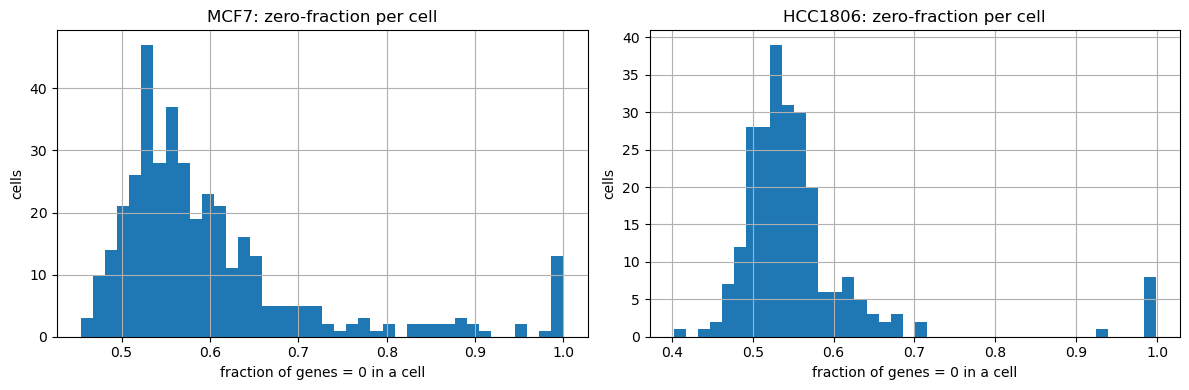

In [ ]:
for name, d in [("MCF7", mcf7_raw), ("HCC1806", hcc_raw)]:
    print(f"{name}: overall zeros = {(d.values == 0).mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, d) in zip(axes, [("MCF7", mcf7_raw), ("HCC1806", hcc_raw)]):
    (d == 0).mean(axis=0).hist(bins=40, ax=ax)
    ax.set_title(f"{name}: zero-fraction per cell")
    ax.set_xlabel("fraction of genes = 0 in a cell")
    ax.set_ylabel("cells")
plt.tight_layout(); plt.show()

About 60% of the MCF7 matrix and 56% of HCC1806 is zero, so even before any cleaning most gene-cell entries are empty. Most cells sit between roughly 0.5 and 0.65 zeros, which is normal for this kind of data. The thing to notice is the small spike near 1.0: a handful of cells where almost every gene reads zero. Those are failed or empty wells with almost nothing captured, and they are exactly the low-quality cells that preprocessing removes. The rest is sparse but informative, which is why the non-zero values, not the zeros, carry the signal.

Next we look at how the non-zero counts are distributed and at how a gene's dropout rate depends on its average expression, which together show what kind of data these counts are.

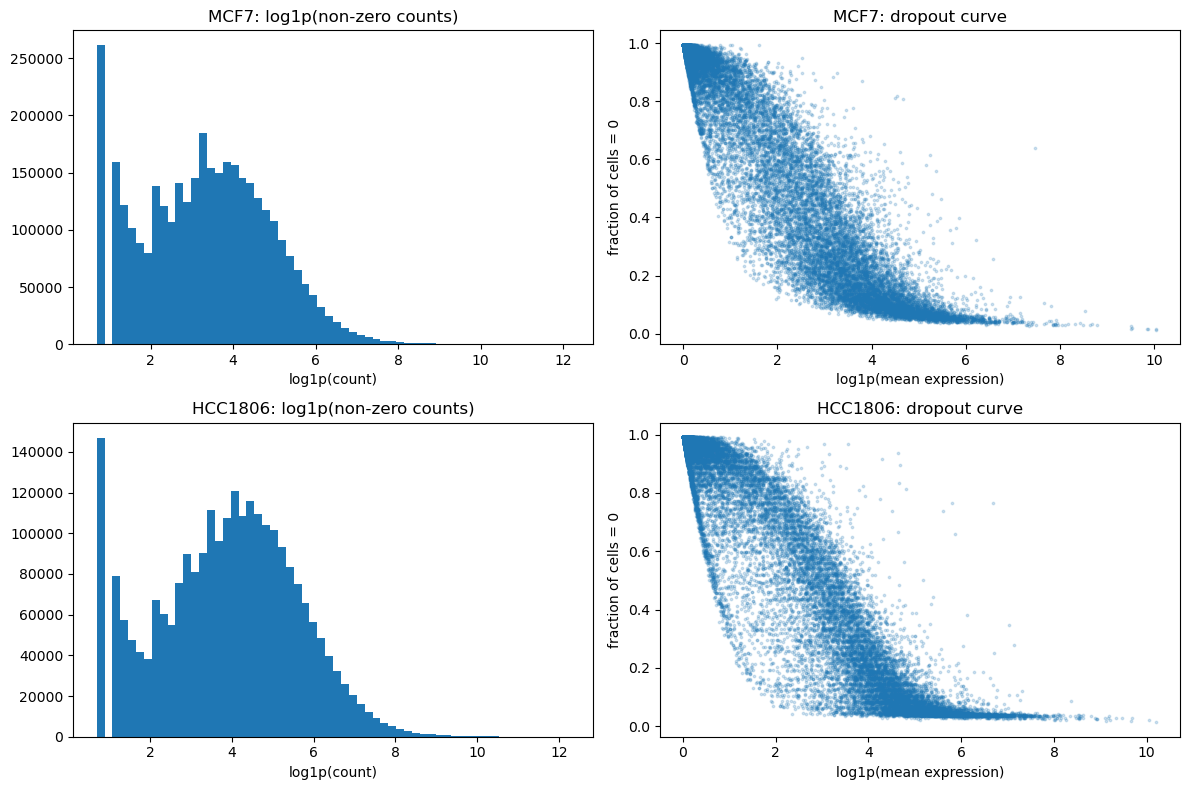

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for row, (name, d) in enumerate([("MCF7", mcf7_raw), ("HCC1806", hcc_raw)]):
    nz = d.values[d.values > 0]
    gmean = d.mean(axis=1)
    dropout = (d == 0).mean(axis=1)

    axes[row, 0].hist(np.log1p(nz), bins=60)
    axes[row, 0].set_title(f"{name}: log1p(non-zero counts)")
    axes[row, 0].set_xlabel("log1p(count)")

    axes[row, 1].scatter(np.log1p(gmean), dropout, s=3, alpha=0.2)
    axes[row, 1].set_title(f"{name}: dropout curve")
    axes[row, 1].set_xlabel("log1p(mean expression)")
    axes[row, 1].set_ylabel("fraction of cells = 0")
plt.tight_layout(); plt.show()

Both cell lines show the same pattern. The non-zero counts are heavily right-skewed even on a log scale: a single read is the most common value and most detected genes sit at low counts, with only a small tail of highly expressed genes. The dropout curves show the zeros are not random. A gene's chance of being zero falls steadily as its average expression rises, so weakly expressed genes are missing in almost every cell while strongly expressed ones are detected everywhere. Because MCF7 and HCC1806 behave the same way, this reflects the data type rather than the cell line. It prompts for log-transforming and filtering out low-expression genes later.

In [33]:
for name, d in [("MCF7", mcf7_raw), ("HCC1806", hcc_raw)]:
    dups = d[d.duplicated(keep=False)]              # genes identical to at least one other gene
    det  = (dups > 0).sum(axis=1)                   # cells each duplicate is detected in
    print(f"{name}: {dups.shape[0]} duplicate genes | "
          f"all-zero among them: {int((dups.sum(axis=1) == 0).sum())} | "
          f"detected in median {int(det.median())} cells "
          f"(all genes median: {int((d > 0).sum(axis=1).median())})")

# show one example group of identical genes (MCF7)
dups = mcf7_raw[mcf7_raw.duplicated(keep=False)]
for _, members in dups.groupby(list(dups.columns)).groups.items():
    if len(members) > 1:
        print("\nexample identical genes:", list(members),
              "| total counts:", mcf7_raw.loc[list(members)].sum(axis=1).to_dict())
        break

MCF7: 56 duplicate genes | all-zero among them: 0 | detected in median 2 cells (all genes median: 125)
HCC1806: 89 duplicate genes | all-zero among them: 0 | detected in median 2 cells (all genes median: 93)

example identical genes: ['HTR5A', 'RNU6-539P'] | total counts: {'HTR5A': 2, 'RNU6-539P': 2}


Checking for duplicate genes, 56 in MCF7 and 89 in HCC1806 have counts identical to another gene, and none are empty, since no gene is zero across every cell. The example report suggests duplicates are usually redundant annotations of the same gene, but that is not the case here. The flagged genes are detected in only about two cells each (median 2, against 125 for all genes), and the example pair HTR5A and RNU6-539P are unrelated genes *quote this* that each carry a single read in the same two cells. So these duplicates are a side effect of extreme sparsity, ultra-low genes colliding on identical count vectors by chance, rather than real annotation redundancy. They need no special deduplication, because the usual gene filter that drops genes seen in fewer than ten cells removes them anyway.

So far we have checked the shape and quality of the data, but not whether it actually carries a hypoxia signal. Before any modelling, it is worth confirming the labels mean what they should. We use genes already known to switch on under low oxygen, such as CA9, VEGFA and NDRG1: if the labels are real, these should read clearly higher in the hypoxic cells than in the normoxic ones. It also gives a first sense of how strong the biological signal is.

In [34]:

markers = ["CA9","VEGFA","SLC2A1","LDHA","PGK1","BNIP3","NDRG1","HK2",
           "PDK1","ALDOA","P4HA1","EGLN3","ANKRD37"]

def marker_table(d):
    labs = get_labels(d)
    rows = []
    for g in markers:
        if g in d.index:
            h = d.loc[g, labs == "Hypoxia"].mean()
            n = d.loc[g, labs == "Normoxia"].mean()
            rows.append((g, round(h, 1), round(n, 1), round((h + 1) / (n + 1), 1)))
    return (pd.DataFrame(rows, columns=["gene", "Hypoxia_mean", "Normoxia_mean", "fold"])
              .sort_values("fold", ascending=False))

mcf7_mk = marker_table(mcf7_raw)
hcc_mk  = marker_table(hcc_raw)
print("MCF7:");    print(mcf7_mk.to_string(index=False))
print("\nHCC1806:"); print(hcc_mk.to_string(index=False))

MCF7:
   gene  Hypoxia_mean  Normoxia_mean  fold
  NDRG1        1001.4           12.0  77.1
    HK2        1432.0           21.7  63.2
    CA9          74.5            1.2  34.5
  VEGFA        1125.4           47.2  23.4
  BNIP3        1840.7           91.1  20.0
   PDK1         193.7           15.0  12.2
  P4HA1         333.6           27.2  11.8
  EGLN3         205.7           16.5  11.8
 SLC2A1        1999.6          194.6  10.2
   PGK1        7072.5         1063.8   6.6
   LDHA        4645.1          818.1   5.7
  ALDOA       22575.3         4406.2   5.1
ANKRD37          39.4            7.4   4.8

HCC1806:
   gene  Hypoxia_mean  Normoxia_mean  fold
    CA9         333.9            3.5  74.2
  EGLN3         401.1            5.8  59.0
  NDRG1         766.8           35.2  21.2
  BNIP3        1130.1          124.5   9.0
 SLC2A1        2571.6          471.7   5.4
    HK2         180.5           32.4   5.4
  P4HA1         835.5          164.5   5.1
   PDK1         192.9           37.4  

Every canonical hypoxia gene reads higher under hypoxia in both lines, with folds from about 2.4x to 77x, so the labels are real and the signal is strong. Two patterns stand out. The folds are generally smaller in HCC1806 (VEGFA 2.4x against 23x in MCF7, HK2 5.4x against 63x), which fits its shorter 24-hour exposure and a less developed response. And the two lines lead with different genes: NDRG1 and HK2 are strongest in MCF7, while CA9 and EGLN3 dominate in HCC1806. So both share the core hypoxia response but emphasise different genes, an early sign that a signature learned on one line may not transfer cleanly to the other.

A risk with any sequencing experiment is that the biological condition lines up with a technical batch. If most hypoxic cells were processed in one batch and most normoxic cells in another, a model could learn the batch rather than the hypoxia signal. To rule this out, we check how hypoxia and normoxia are spread across the sequencing batches: lanes for MCF7, PCR plates for HCC1806.

In [ ]:
print("MCF7 — Lane x Condition:")
print(pd.crosstab(mcf7_meta["Lane"], mcf7_meta["Condition"]))

print("\nHCC1806 — PCR Plate x Condition:")
print(pd.crosstab(hcc_meta["PCR Plate"], hcc_meta["Condition"]))

MCF7 — Lane x Condition:
Condition      Hypo  Norm
Lane                     
output.STAR.1    48    48
output.STAR.2    48    48
output.STAR.3    48    48
output.STAR.4    47    48

HCC1806 — PCR Plate x Condition:
Condition  Hypo  Normo
PCR Plate             
1            32     32
2            34     29
3            39     29
4            21     27


MCF7 is cleanly balanced: every lane holds 48 hypoxia and 48 normoxia cells (lane 4 is 47/48), so condition is independent of lane and cannot be mistaken for the signal. HCC1806 is only roughly balanced: both conditions appear in every plate, but plate 3 leans hypoxia (39/29) and plate 4 leans normoxia (21/27). That is not a hard confound, since no plate is one-sided, but the imbalance is worth noting, as a model on HCC1806 could absorb a little plate-related variation along with the hypoxia signal.

### Preprocessing of SmartSeq

whateva rares puts

#### Comparison of his results to the ones given to us

i was thinking here we run some code to compare how similar his files are to the ones given. i alr ran the code and saw the similarities are small so maybe here a short paragraph justyfying why we proceed with ones provided to us to have consistency.

### Filtered data analysis 

We initially diagnosed the raw data, but only SmartSeq exists in raw form. From here we switch to the processed files provided with the course, which cover all four datasets, so the two cell lines and the two technologies can finally be compared on equal footing. Everything is now at the same processing stage, so the differences we see are real, not artefacts of one set being cleaned and another not.

In [47]:
processed = [
    ("SmartSeq MCF7",    SMART / "MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt"),
    ("SmartSeq HCC1806", SMART / "HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt"),
    ("DropSeq MCF7",     DROP / "MCF7_Filtered_Normalised_3000_Data_train.txt"),
    ("DropSeq HCC1806",  DROP / "HCC1806_Filtered_Normalised_3000_Data_train.txt"),
]

from IPython.display import display

for name, path in processed:
    d = load_matrix(path)
    print(f"=== {name} === {d.shape} (genes x cells)")
    display(d.iloc[:4, :3])
    del d



=== SmartSeq MCF7 === (3000, 250) (genes x cells)


,output.STAR.2_B3_Norm_S57_Aligned.sortedByCoord.out.bam,output.STAR.2_B4_Norm_S58_Aligned.sortedByCoord.out.bam,output.STAR.2_B5_Norm_S59_Aligned.sortedByCoord.out.bam
CYP1B1,343,131,452
CYP1B1-AS1,140,59,203
CYP1A1,0,0,0
NDRG1,0,1,0


=== SmartSeq HCC1806 === (3000, 182) (genes x cells)


,output.STAR.PCRPlate1G12_Normoxia_S32_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1G1_Hypoxia_S102_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1G2_Hypoxia_S2_Aligned.sortedByCoord.out.bam
DDIT4,0,8739,13098
ANGPTL4,48,2101,14032
CALML5,0,55,0
KRT14,321,96,0


=== DropSeq MCF7 === (3000, 21626) (genes x cells)


,AAAAACCTATCG_Normoxia,AAAACAACCCTA_Normoxia,AAAACACTCTCA_Normoxia
MALAT1,1,3,3
MT-RNR2,0,0,0
NEAT1,0,0,0
H1-5,0,0,0


=== DropSeq HCC1806 === (3000, 14682) (genes x cells)


,AAAAAACCCGGC_Normoxia,AAAACCGGATGC_Normoxia,AAAACGAGCTAG_Normoxia
H1-5,2,2,5
MALAT1,3,3,2
MT-RNR2,0,0,0
ARVCF,0,0,0


A first look at the four filtered matrices shows they share a layout, 3,000 genes by a varying number of cells, but little else. The cell labels differ by technology: SmartSeq keeps the full sequencing filenames, which still carry the batch information (lane for MCF7, plate for HCC1806), while DropSeq uses short barcodes with no batch information at all. The values differ just as much, with SmartSeq cells holding large graded counts and DropSeq cells nearly empty, their few non-zero entries being single reads on the most abundant genes such as MALAT1

In [48]:
rows = []
for name, path in processed:
    d = load_matrix(path)
    labs = get_labels(d)
    rows.append({
        "dataset": name,
        "genes": d.shape[0],
        "cells": d.shape[1],
        "%zeros": round((d.values == 0).mean() * 100, 1),
        "median_lib": round(float(d.sum(axis=0).median()), 1),
        "Hypoxia": int((labs == "Hypoxia").sum()),
        "Normoxia": int((labs == "Normoxia").sum()),
    })
    del d

glance = pd.DataFrame(rows)
glance


,dataset,genes,cells,%zeros,median_lib,Hypoxia,Normoxia
0,SmartSeq MCF7,3000,250,63.6,330296.0,124,126
1,SmartSeq HCC1806,3000,182,70.7,497586.5,97,85
2,DropSeq MCF7,3000,21626,97.5,100.0,8921,12705
3,DropSeq HCC1806,3000,14682,97.6,102.0,8899,5783


The gene panel is fixed at 3,000 for all four, but otherwise they fall into two regimes. SmartSeq has few cells (250 and 182) sequenced deeply, with median library sizes of 330k–500k and moderate sparsity (64–71%). DropSeq has tens of thousands of cells (21,626 and 14,682) sequenced very shallowly, with median library sizes near 100 and 97.5% sparsity, so depth per cell differs by several thousand-fold. Class balance also splits by technology: SmartSeq is close to even, while DropSeq is skewed in opposite directions, MCF7 leaning normoxia (8,921 vs 12,705) and HCC1806 leaning hypoxia (8,899 vs 5,783). That skew is worth flagging for the modelling step.

To see the sparsity as a pattern rather than a single percentage, we plot a 100-gene by 100-cell corner of each matrix, with black marking a detected gene and white a zero.

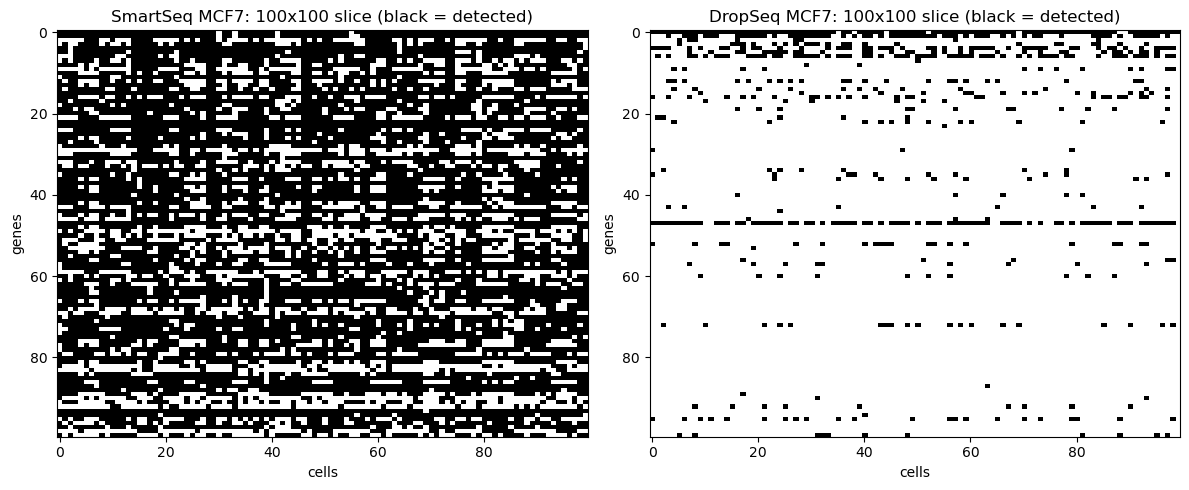

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, path) in zip(axes, [processed[0], processed[2]]):   # SmartSeq MCF7 vs DropSeq MCF7
    d = load_matrix(path)
    ax.imshow(d.iloc[:100, :100] > 0, aspect="auto", cmap="Greys", interpolation="nearest")
    ax.set_title(f"{name}: 100x100 slice (black = detected)")
    ax.set_xlabel("cells"); ax.set_ylabel("genes")
    del d
plt.tight_layout(); plt.show()

The sparsity plots showed how often genes are detected; this looks at how large those detected values are. For each dataset we take every non-zero value and plot its distribution on a log scale, so the magnitude of expression can be compared across the two technologies at the same processing stage.

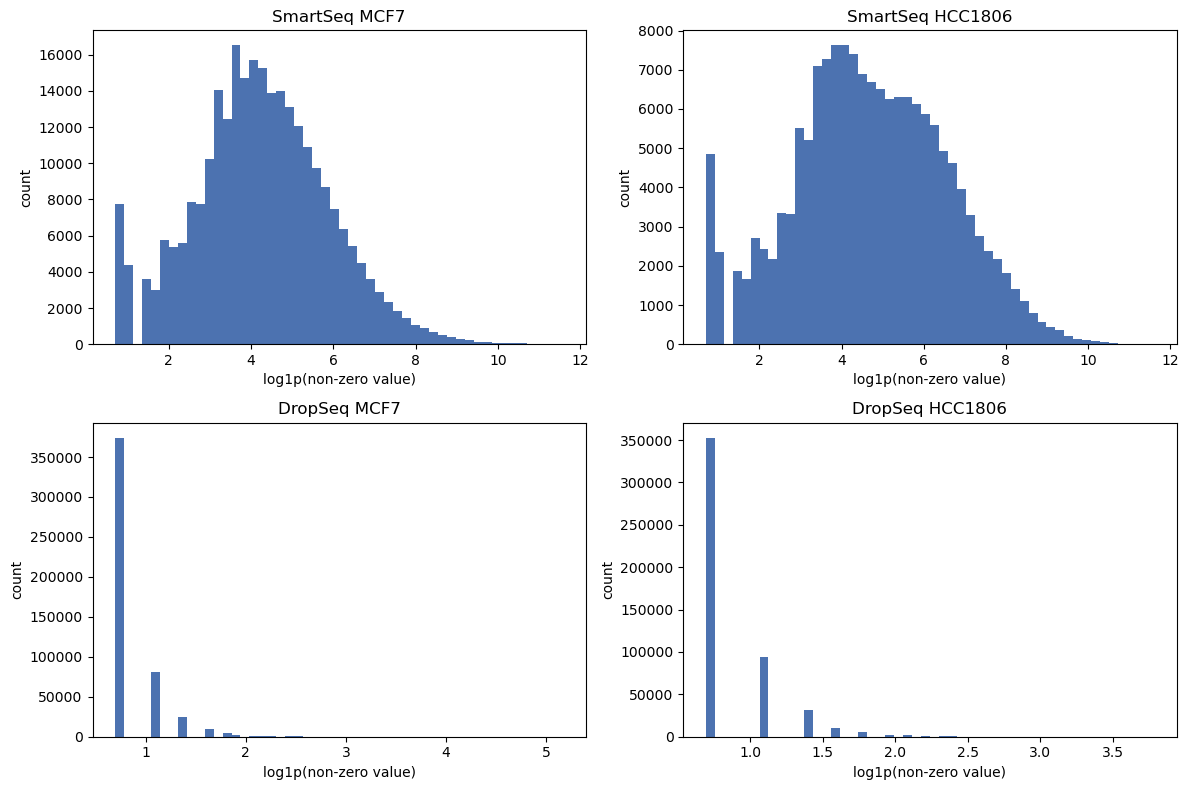

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
rng = np.random.default_rng(0)
for ax, (name, path) in zip(axes.flat, processed):
    d = load_matrix(path)
    vals = d.values[d.values > 0]
    if vals.size > 500000:                 # sample to keep the big DropSeq matrices fast
        vals = rng.choice(vals, 500000, replace=False)
    ax.hist(np.log1p(vals), bins=50, color="#4C72B0")
    ax.set_title(name)
    ax.set_xlabel("log1p(non-zero value)"); ax.set_ylabel("count")
    del d
plt.tight_layout(); plt.show()

The two technologies behave very differently. In SmartSeq the detected values span a wide range, from single reads up to high counts, with log values reaching about 10, giving a broad graded distribution in both lines. In DropSeq almost every detected value is a single read: the distribution collapses to a spike at the low end, with a maximum log value of only about 3 to 5. So DropSeq detections are not only rare but tiny, a gene is usually either absent or seen exactly once, leaving the data close to binary, while SmartSeq records graded expression. A DropSeq cell therefore carries far less quantitative information per gene, which limits what a model can learn from it and helps explain why DropSeq is the harder case.

#### Shared gene panel

Each dataset keeps its own 3,000 most informative genes, chosen from that dataset alone. Nothing forces those choices to agree, so the four panels may not even describe the same genes. This matters directly for the project's central question: if a model is trained on one dataset and tested on another, it can only use genes the two have in common, so the overlap between panels sets a hard ceiling on how well any model can transfer. Here we measure that overlap, pairwise and across all four.

In [52]:
panels = {}
for name, path in processed:
    panels[name] = set(pd.read_csv(path, sep=" ", usecols=[0], index_col=0).index)

names = list(panels)
overlap = pd.DataFrame(index=names, columns=names, dtype=int)
for a in names:
    for b in names:
        overlap.loc[a, b] = len(panels[a] & panels[b])

print("Shared genes between panels (out of 3000):")
print(overlap)

core = set.intersection(*panels.values())
print(f"\nGenes shared by all four datasets: {len(core)}")

Shared genes between panels (out of 3000):
                  SmartSeq MCF7  SmartSeq HCC1806  DropSeq MCF7  \
SmartSeq MCF7            3000.0            1208.0         496.0   
SmartSeq HCC1806         1208.0            3000.0         445.0   
DropSeq MCF7              496.0             445.0        3000.0   
DropSeq HCC1806           547.0             516.0         834.0   

                  DropSeq HCC1806  
SmartSeq MCF7               547.0  
SmartSeq HCC1806            516.0  
DropSeq MCF7                834.0  
DropSeq HCC1806            3000.0  

Genes shared by all four datasets: 70


The panels overlap remarkably little. Out of 3,000 genes, the two SmartSeq datasets share 1,208 and the two DropSeq datasets 834, so even within one technology the two cell lines agree on at most 40% of their genes. Across technologies it is worse: the same cell line shares only about 500 genes between SmartSeq and DropSeq (496 for MCF7, 516 for HCC1806), roughly 17%. Only 70 genes, 2.3%, are common to all four. The clearest pattern is that technology divides the panels more than cell line does, since same-technology pairs share more genes than the same cell line measured across technologies. Which 3,000 genes look most informative is driven more by the sequencing platform than by the biology. This sets a hard ceiling on generalization: a model trained on one dataset and applied to another can only use the genes they share, so a cross-technology model has only about 17% of its features even present in the target. It also predicts the asymmetry the generalization section reports, transfer across cell lines, with more shared genes, should beat transfer across technologies, with fewer.

The obvious question is whether those few shared genes are the biologically important ones. If the canonical hypoxia markers survive into every panel, then despite the low overlap there is still a stable biological core a cross-dataset model could lean on. If they do not, even the key hypoxia genes are being dropped inconsistently, which would make generalisation harder still. Here we check which markers are retained in each panel and which reach the shared core.

In [54]:
markers = ["CA9","VEGFA","SLC2A1","LDHA","PGK1","BNIP3","NDRG1","HK2",
           "PDK1","ALDOA","P4HA1","EGLN3","ANKRD37"]

rows = []
for g in markers:
    row = {"gene": g}
    for name in panels:
        row[name] = "yes" if g in panels[name] else "-"
    row["all 4"] = "yes" if g in core else "-"
    rows.append(row)

marker_panel = pd.DataFrame(rows).set_index("gene")
print("Hypoxia markers retained in each panel:")
print(marker_panel)
print(f"\nMarkers in the 70-gene shared core: {sorted(set(markers) & core)}")

Hypoxia markers retained in each panel:
        SmartSeq MCF7 SmartSeq HCC1806 DropSeq MCF7 DropSeq HCC1806 all 4
gene                                                                     
CA9               yes              yes            -             yes     -
VEGFA             yes              yes            -               -     -
SLC2A1            yes              yes            -             yes     -
LDHA              yes              yes            -             yes     -
PGK1              yes              yes          yes             yes   yes
BNIP3             yes              yes            -             yes     -
NDRG1             yes              yes            -             yes     -
HK2               yes              yes            -             yes     -
PDK1              yes                -            -               -     -
ALDOA             yes              yes            -               -     -
P4HA1             yes              yes            -             yes     

The result is split by technology. The two SmartSeq panels keep almost every canonical marker (12 of 13 for MCF7, 11 for HCC1806), so on deep data the variance-based selection naturally retains the hypoxia biology. DropSeq is inconsistent: HCC1806 still keeps 9 of the 13, but MCF7 keeps only one, PGK1. So under heavy dropout the gene-selection step can strip out almost all the textbook hypoxia genes, and it does so differently from one dataset to the next. Only PGK1, a broadly expressed glycolytic gene, survives into all four panels, so the entire shared core holds just a single canonical marker. Two points follow. The biology is not gone, the earlier fold changes show the markers respond, but variance selection on sparse data fails to rank the more hypoxia-specific, lowly detected genes, so they drop out. And the shared core is biologically thin: a model limited to genes common to all four would have almost none of the known hypoxia signature, which compounds the overlap problem from 3.5.

#### Gene to gene correlation

So far we have treated the 3,000 genes as 3,000 separate features. But genes rarely act alone: those in the same pathway tend to rise and fall together, so many of the features may be carrying the same information. Before any modelling it is worth asking how independent the genes really are, because if they are highly correlated, the data holds far fewer effective dimensions than 3,000, and dimensionality reduction becomes the natural next step. We measure this with gene-to-gene correlation, comparing a deep dataset (SmartSeq) against a shallow one (DropSeq).

SmartSeq MCF7: median |r| = 0.206, fraction |r|>0.3 = 31.3%
DropSeq MCF7: median |r| = 0.019, fraction |r|>0.3 = 0.1%


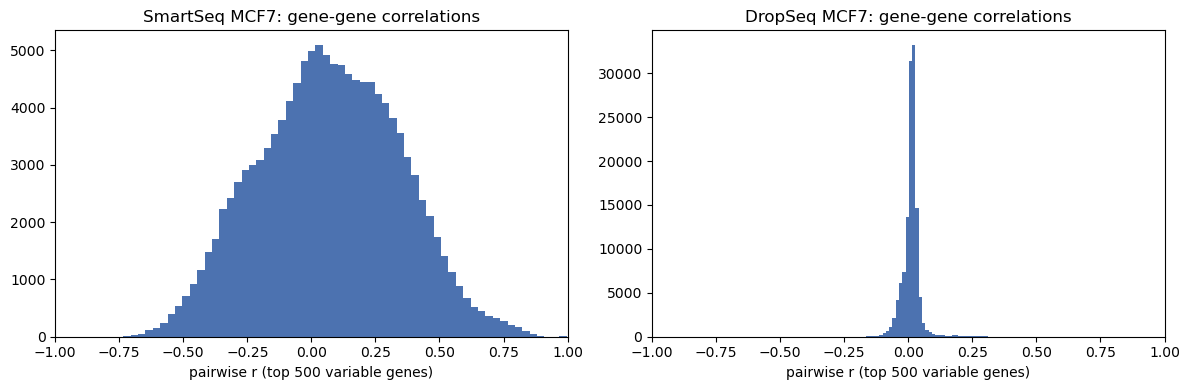

In [55]:
results = {}
for name, path in [("SmartSeq MCF7", processed[0][1]), ("DropSeq MCF7", processed[2][1])]:
    d = load_matrix(path)
    x = np.log1p(d.values)
    idx = np.argsort(x.var(axis=1))[-500:]        # top 500 most variable genes
    c = np.corrcoef(x[idx])
    off = c[np.triu_indices_from(c, k=1)]
    off = off[~np.isnan(off)]
    results[name] = off
    print(f"{name}: median |r| = {np.median(np.abs(off)):.3f}, "
          f"fraction |r|>0.3 = {(np.abs(off) > 0.3).mean():.1%}")
    del d, x, c

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name in zip(axes, results):
    ax.hist(results[name], bins=60, color="#4C72B0")
    ax.set_title(f"{name}: gene-gene correlations")
    ax.set_xlabel("pairwise r (top 500 variable genes)"); ax.set_xlim(-1, 1)
plt.tight_layout(); plt.show()

The two technologies look completely different. In SmartSeq the gene-gene correlations spread widely: median absolute correlation 0.21, with 31% of gene pairs above 0.3, so much of the 3,000-gene panel moves together in co-expression modules. The features are far from independent, so the data carries many fewer effective dimensions than 3,000 and dimensionality reduction is well justified. In DropSeq the same measurement collapses to a spike at zero (median 0.019, almost no pairs above 0.3), not because the biology is gone but because dropout removes the co-occurrence needed to see it: with so few genes detected per cell, pairs rarely appear together and their correlations wash out. So reducing dimensions should work cleanly on SmartSeq, where there is real structure to compress, but has little to grip onto in DropSeq, which already predicts the unsupervised step will behave very differently across the two technologies.

*my last sentance is good segway into unsupervised.*
